In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

In [2]:
# =========================
# Load data
# =========================
df = pd.read_csv("Housing_cleaned.csv")

X = df.drop("price", axis=1)
y = df["price"]

In [3]:
# =========================
# Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# =========================
# Standard Scaler
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 1. Linear Regression
# =========================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

df_results = pd.DataFrame(y_pred_lr, columns=['Predicted_Price'])

# Xuất ra file CSV
df_results.to_csv('predictions.csv', index=False)

print("Đã xuất kết quả dự đoán ra file 'predictions.csv' thành công!")


Đã xuất kết quả dự đoán ra file 'predictions.csv' thành công!


In [5]:
# =========================
# 2. Random Forest + GridSearch
# =========================
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True]
}

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Best params:", grid_search.best_params_)

Best params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [6]:
# =========================
# Evaluation function
# =========================
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rrmse = rmse / np.mean(y_true)

    return rmse, rrmse, r2, mae

In [7]:
# =========================
# Evaluate models
# =========================
lr_metrics = evaluate(y_test, y_pred_lr)
rf_metrics = evaluate(y_test, y_pred_rf)

print("Linear Regression:", lr_metrics)
print("Random Forest:", rf_metrics)

Linear Regression: (np.float64(1324506.9600914407), np.float64(0.26450269666908877), 0.6529242642153174, 970043.4039201644)
Random Forest: (np.float64(1400619.501556149), np.float64(0.2797022940093423), 0.6118888664071445, 1010525.2975295656)


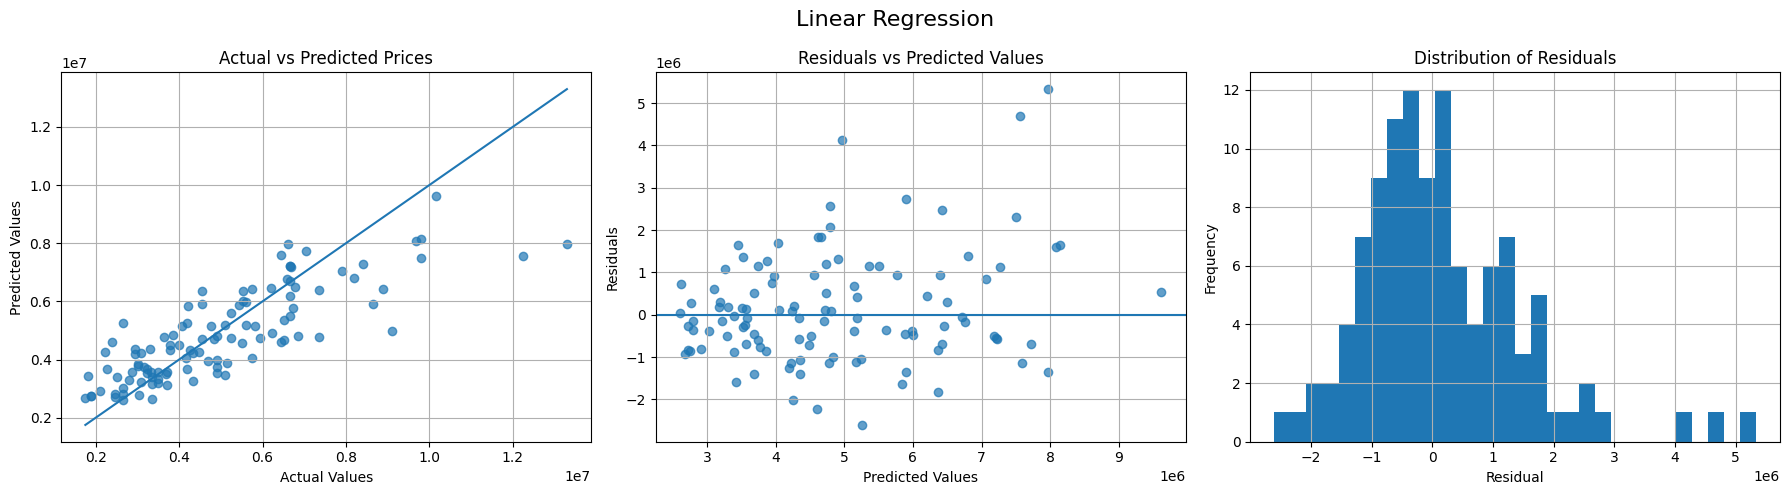

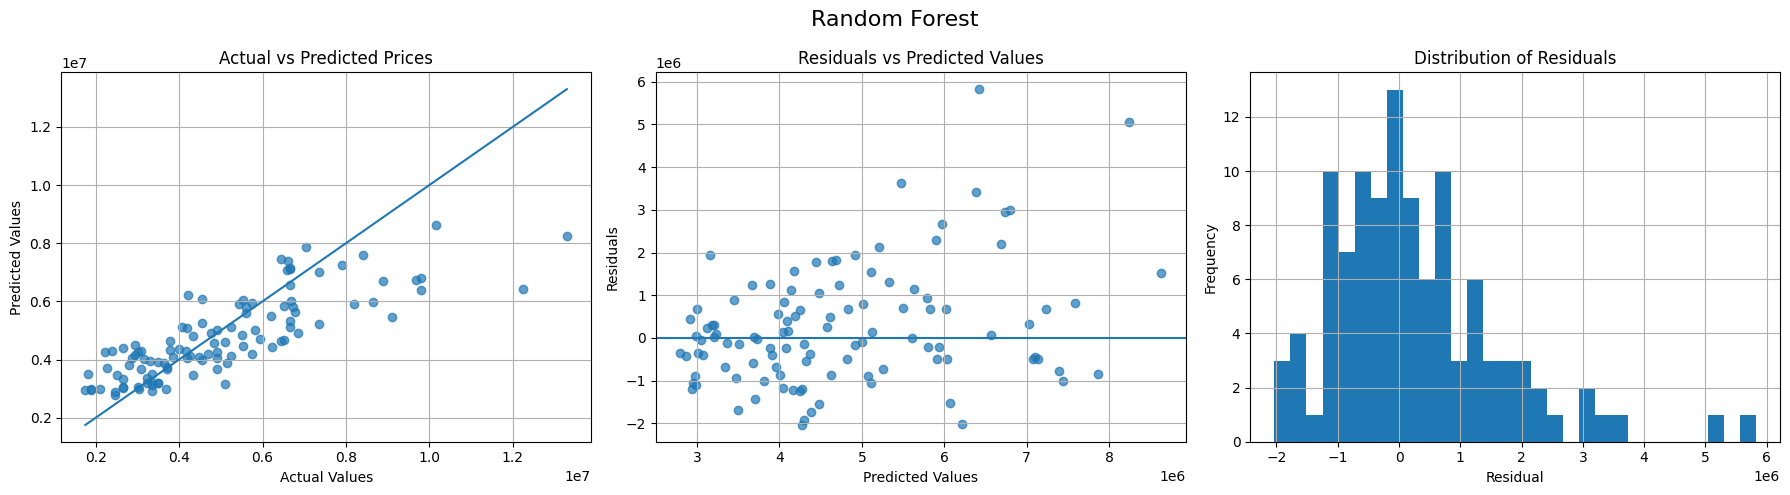

In [8]:
def plot_pretty(y_true, y_pred, title):
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # =========================
    # (a) Predictions vs Actual
    # =========================
    axes[0].scatter(y_true, y_pred, alpha=0.7)

    # vẽ đường y = x (ideal line)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[0].plot([min_val, max_val], [min_val, max_val])

    axes[0].set_title("Actual vs Predicted Prices")
    axes[0].set_xlabel("Actual Values")
    axes[0].set_ylabel("Predicted Values")
    axes[0].grid(True)

    # =========================
    # (b) Residuals vs Predicted
    # =========================
    axes[1].scatter(y_pred, residuals, alpha=0.7)
    axes[1].axhline(0)

    axes[1].set_title("Residuals vs Predicted Values")
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].grid(True)

    # =========================
    # (c) Distribution of Residuals
    # =========================
    axes[2].hist(residuals, bins=30)
    axes[2].set_title("Distribution of Residuals")
    axes[2].set_xlabel("Residual")
    axes[2].set_ylabel("Frequency")
    axes[2].grid(True)

    # =========================
    # Title chung
    # =========================
    fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()

plot_pretty(y_test, y_pred_lr, "Linear Regression")
plot_pretty(y_test, y_pred_rf, "Random Forest")